# Scaling method selection for metabolomics data

This notebook is designed to help select an **appropriate scaling method before running the main preprocessing workflow.**

It includes:
- Loading raw data
- Visualizing the raw intensity distribution
- Comparing distributions before and after log10 transformation
- Checking sample-wise total intensity
- Comparing PCA results across scaling methods (`none`, `pareto`, `auto`, `log_pareto`, and `log_auto`)
- Providing a simple recommendation based on QC clustering


## 1. Load packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 2. Load raw dataset

Dataset requirements:
- A `Name` column
- A `Label` column
- Numeric values in all remaining feature columns


In [ ]:
cd C:\Github_repository\Metabolomics_Tutorial\Data

In [3]:
original_dataset = pd.read_excel('Compounds_merged.xlsx', sheet_name='fecal_neg_tp')  #Edit
original_dataset.head(3)

,Name,Label,296.61697-8.708,487.23704-10.048,421.22633-15.475,134.89469-16.398,421.22647-16.397,197.80811-1.288,134.8947-16.053,296.61713-13.231,...,555.02091-1.006,318.8747-0.972,454.84771-0.969,107.90717-0.945,187.02236-1.021,520.83183-0.955,356.91342-0.925,127.00133-1,443.23-9.348,111.08159-9.143
0,BL1,blank,3.050975e+08,67782.193316,4.777520e+09,2.142431e+09,1.687702e+08,6.688440e+08,5.139073e+08,8.740116e+07,...,14840.367739,13204.760207,12185.791235,15670.186378,17898.609383,8919.031901,14065.068548,14605.456286,6852.144074,11566.179604
1,BL2,blank,2.441851e+08,68640.603518,5.295591e+09,1.102732e+09,1.816002e+08,6.163625e+08,5.495560e+08,8.065268e+07,...,14810.837213,14114.038259,13024.903218,15744.776728,17897.553088,9533.195265,14431.061747,14576.393205,5980.761393,16047.393212
2,BL3,blank,2.547846e+08,131920.154644,5.626814e+09,3.652175e+08,2.038520e+08,6.037269e+08,1.194490e+09,7.750460e+07,...,15149.226047,14829.088002,13684.774867,15642.449788,16922.996247,9309.270159,14207.751912,15316.318851,6566.693629,18756.513809


## 3. Check raw data distribution before choosing scaling

This step helps **evaluate the data distribution before selecting a scaling method.**

Things to check:
- Is the raw data strongly right-skewed?
- Does the distribution become more stable after log10 transformation?
- Are a few high-intensity features dominating the dataset?
- How are the QC samples distributed?


In [4]:
def plot_raw_distribution(original_dataset, qc_label='Mix'):
    feature_cols = [col for col in original_dataset.columns if col not in ['Name', 'Label']]
    X = original_dataset[feature_cols].copy()

    all_values = X.to_numpy().flatten()
    all_values = all_values[~np.isnan(all_values)]
    positive_values = all_values[all_values > 0]

    print('Number of samples:', original_dataset.shape[0])
    print('Number of features:', len(feature_cols))
    print('\nSummary of first 10 features:')
    display(X.describe().T[['mean', 'std', 'min', '50%', 'max']].head(10))

    plt.figure(figsize=(7, 4))
    plt.hist(all_values, bins=50)
    plt.xlabel('Raw intensity')
    plt.ylabel('Frequency')
    plt.title('Distribution of all raw feature values')
    plt.tight_layout()
    plt.show()

    if len(positive_values) > 0:
        plt.figure(figsize=(7, 4))
        plt.hist(np.log10(positive_values), bins=50)
        plt.xlabel('log10(raw intensity)')
        plt.ylabel('Frequency')
        plt.title('Distribution after log10 transform')
        plt.tight_layout()
        plt.show()
    else:
        print('No positive values were found for log10 transformation.')

    sample_total = X.sum(axis=1)
    plt.figure(figsize=(7, 4))
    plt.boxplot(sample_total)
    plt.ylabel('Sum of feature intensities per sample')
    plt.title('Sample-wise total intensity distribution')
    plt.tight_layout()
    plt.show()

    if qc_label in original_dataset['Label'].astype(str).unique():
        qc_df = original_dataset[original_dataset['Label'] == qc_label]
        qc_values = qc_df[feature_cols].to_numpy().flatten()
        qc_values = qc_values[~np.isnan(qc_values)]

        plt.figure(figsize=(7, 4))
        plt.hist(qc_values, bins=50)
        plt.xlabel('QC raw intensity')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of QC feature values ({qc_label})')
        plt.tight_layout()
        plt.show()
    else:
        print(f"QC label '{qc_label}' was not found in the dataset.")

    raw_skew = pd.Series(all_values).skew() if len(all_values) > 0 else np.nan
    log_skew = pd.Series(np.log10(positive_values)).skew() if len(positive_values) > 0 else np.nan

    feature_means = X.mean(axis=0)
    dynamic_range_ratio = np.nan
    if (feature_means > 0).any():
        dynamic_range_ratio = feature_means.max() / feature_means[feature_means > 0].min()

    print('\nInterpretation guide:')
    print(f'- Raw skewness: {raw_skew:.3f}' if pd.notna(raw_skew) else '- Raw skewness: NA')
    print(f'- Log10 skewness: {log_skew:.3f}' if pd.notna(log_skew) else '- Log10 skewness: NA')
    print(f'- Dynamic range ratio: {dynamic_range_ratio:.3f}' if pd.notna(dynamic_range_ratio) else '- Dynamic range ratio: NA')
    print('\nPractical hints:')
    print('- If raw distribution is strongly right-skewed, log transform may help.')
    print('- If a few large features dominate, pareto or auto scaling may be useful.')
    print('- Pareto is often a balanced default for metabolomics.')
    print('- Auto scaling can emphasize small features but may amplify noise.')

Number of samples: 77
Number of features: 9085

Summary of first 10 features:


,mean,std,min,50%,max
296.61697-8.708,2.714429e+09,3.255301e+09,1.185463e+07,1.224382e+09,1.299683e+10
487.23704-10.048,7.723143e+08,1.175500e+09,4.391369e+04,3.668147e+08,6.583570e+09
421.22633-15.475,4.760540e+09,4.980034e+08,3.536732e+09,4.774692e+09,6.075236e+09
134.89469-16.398,1.317996e+09,4.911513e+08,2.966736e+08,1.278050e+09,2.763403e+09
421.22647-16.397,7.929892e+08,5.711390e+08,1.687702e+08,5.883332e+08,2.412237e+09
197.80811-1.288,4.456378e+08,2.327168e+08,2.075838e+08,4.071212e+08,2.153215e+09
134.8947-16.053,6.792211e+08,3.001372e+08,2.424464e+08,5.751131e+08,1.980660e+09
296.61713-13.231,2.259506e+08,3.426104e+08,3.378329e+05,9.657558e+07,1.672252e+09
197.8081-1.761,1.097158e+09,1.848122e+08,7.478690e+08,1.060198e+09,1.620938e+09
134.89467-16.9,7.426163e+08,3.442010e+08,1.488264e+08,8.137624e+08,1.605959e+09


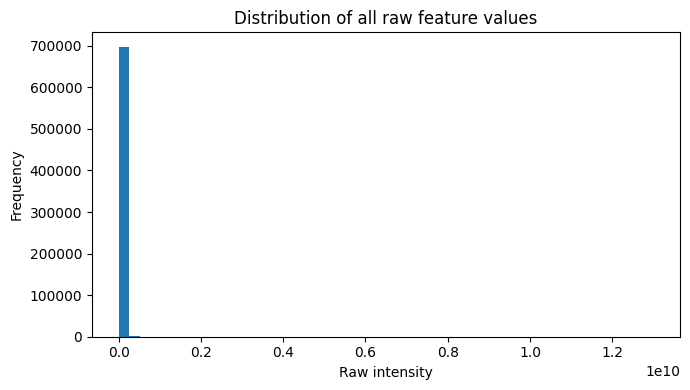

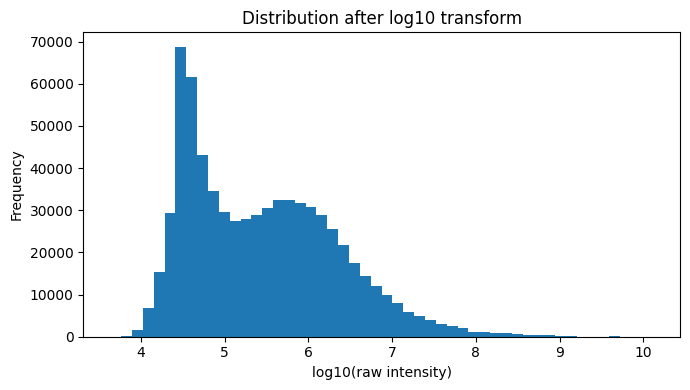

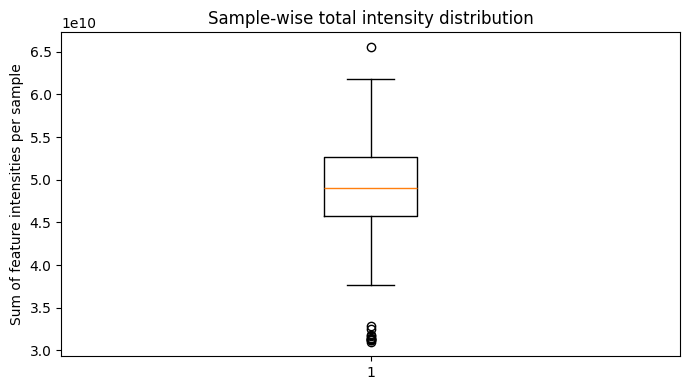

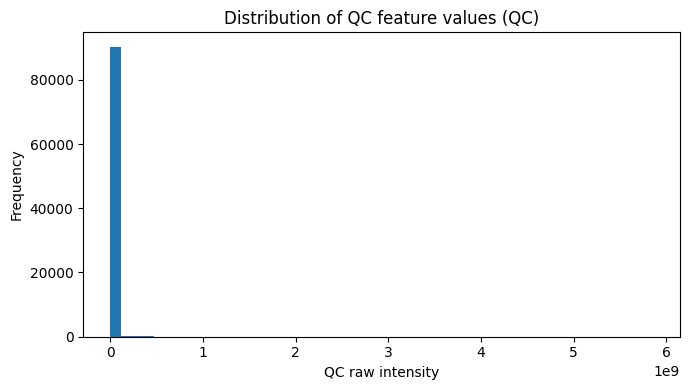


Interpretation guide:
- Raw skewness: 65.260
- Log10 skewness: 0.685
- Dynamic range ratio: 383184.625

Practical hints:
- If raw distribution is strongly right-skewed, log transform may help.
- If a few large features dominate, pareto or auto scaling may be useful.
- Pareto is often a balanced default for metabolomics.
- Auto scaling can emphasize small features but may amplify noise.


In [5]:
plot_raw_distribution(original_dataset, qc_label='QC')  #Edit: if your QC label is different, change 'QC' to the appropriate label in your dataset.

## 4. Compare scaling methods by PCA

This step generates PCA plots for each scaling method and compares how tightly the QC samples cluster using the `qc_cluster_score`.

Interpretation:
- A lower `qc_cluster_score` indicates tighter QC clustering.
- Even if the biological groups appear well separated, a scaling method may not be appropriate if the QC samples show unstable clustering.


In [6]:
def _apply_scaling_matrix(X, method='none'):
    X = X.copy()
    
    if method == 'none':
        return X

    mean_val = X.mean(axis=0)
    sd_val = X.std(axis=0, ddof=1).replace(0, np.nan)

    if method == 'pareto':
        return (X - mean_val) / np.sqrt(sd_val)
    elif method == 'auto':
        return (X - mean_val) / sd_val
    else:
        raise ValueError("method must be one of: 'none', 'pareto', 'auto'")

def _apply_log10_transform(X):
    X = X.copy()
    min_positive = X[X > 0].min().min()
    if pd.isna(min_positive):
        raise ValueError('No positive values found for log10 transform.')
    pseudo = min_positive / 2
    return np.log10(X + pseudo)

def _qc_cluster_score(pca_df, qc_label='Mix'):
    qc = pca_df[pca_df['Label'] == qc_label].copy()
    if len(qc) < 2:
        return np.nan
    center = qc[['PC1', 'PC2']].mean(axis=0)
    dist = np.sqrt(((qc[['PC1', 'PC2']] - center) ** 2).sum(axis=1))
    return dist.mean()

def compare_scaling_methods_pca(original_dataset, qc_label='Mix', methods=None):
    if methods is None:
        methods = ['none', 'pareto', 'auto', 'log_pareto', 'log_auto']

    feature_cols = [col for col in original_dataset.columns if col not in ['Name', 'Label']]
    X_raw = original_dataset[feature_cols].copy()
    sample_info = original_dataset[['Name', 'Label']].copy()

    results = []
    pca_outputs = {}

    for method in methods:
        X = X_raw.copy()

        if method == 'none':
            X_proc = X
        elif method == 'pareto':
            X_proc = _apply_scaling_matrix(X, method='pareto')
        elif method == 'auto':
            X_proc = _apply_scaling_matrix(X, method='auto')
        elif method == 'log_pareto':
            X_log = _apply_log10_transform(X)
            X_proc = _apply_scaling_matrix(X_log, method='pareto')
        elif method == 'log_auto':
            X_log = _apply_log10_transform(X)
            X_proc = _apply_scaling_matrix(X_log, method='auto')
        else:
            raise ValueError(f'Unknown method: {method}')

        X_proc = X_proc.replace([np.inf, -np.inf], np.nan)
        X_proc = X_proc.dropna(axis=1, how='any')

        pca = PCA(n_components=2)
        scores = pca.fit_transform(X_proc)
        explained = pca.explained_variance_ratio_ * 100

        pca_df = sample_info.copy()
        pca_df['PC1'] = scores[:, 0]
        pca_df['PC2'] = scores[:, 1]

        qc_score = _qc_cluster_score(pca_df, qc_label=qc_label)

        results.append({
            'method': method,
            'n_features_used': X_proc.shape[1],
            'PC1_explained_percent': explained[0],
            'PC2_explained_percent': explained[1],
            'qc_cluster_score': qc_score
        })

        pca_outputs[method] = {
            'pca_df': pca_df,
            'explained': explained
        }

    result_df = pd.DataFrame(results).sort_values('qc_cluster_score', na_position='last').reset_index(drop=True)
    return result_df, pca_outputs

def plot_scaling_method_pca(pca_outputs):
    for method, obj in pca_outputs.items():
        pca_df = obj['pca_df']
        explained = obj['explained']

        plt.figure(figsize=(6, 5))
        labels = pca_df['Label'].dropna().unique()

        for label in labels:
            tmp = pca_df[pca_df['Label'] == label]
            plt.scatter(tmp['PC1'], tmp['PC2'], label=label)

        plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
        plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
        plt.title(f'PCA after {method}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

,method,n_features_used,PC1_explained_percent,PC2_explained_percent,qc_cluster_score
0,log_pareto,9085,43.159238,29.726359,2.912178e+00
1,log_auto,9085,39.309251,28.229263,3.943168e+00
2,auto,9085,34.087931,15.240221,5.369587e+00
3,pareto,9085,29.294206,15.937615,1.612593e+04
4,none,9085,75.414320,9.444109,7.254250e+08


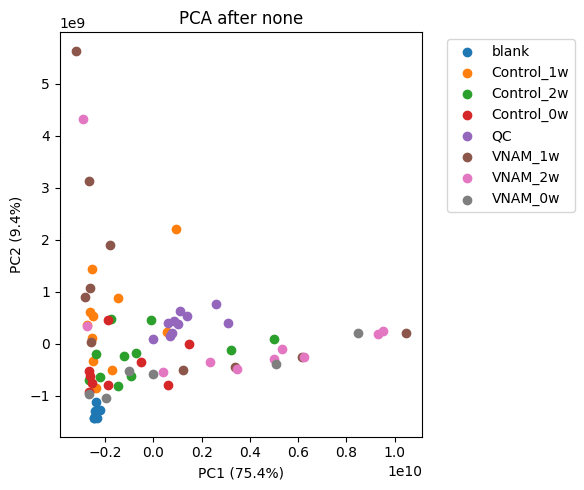

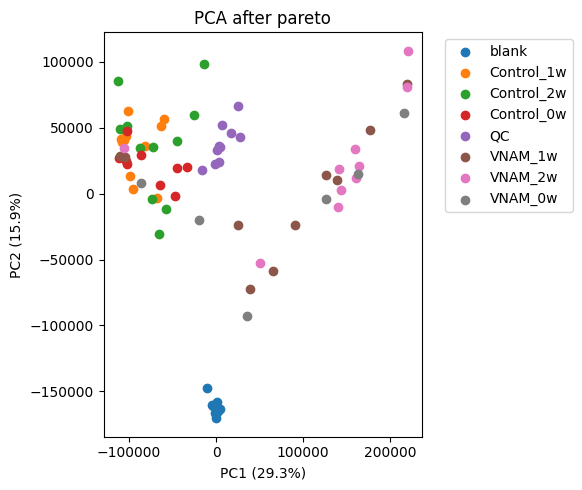

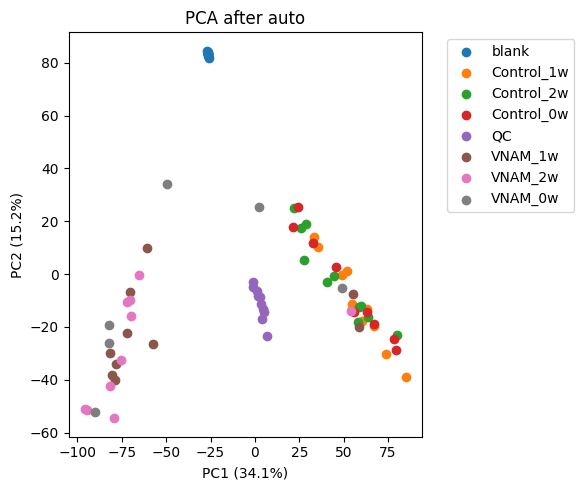

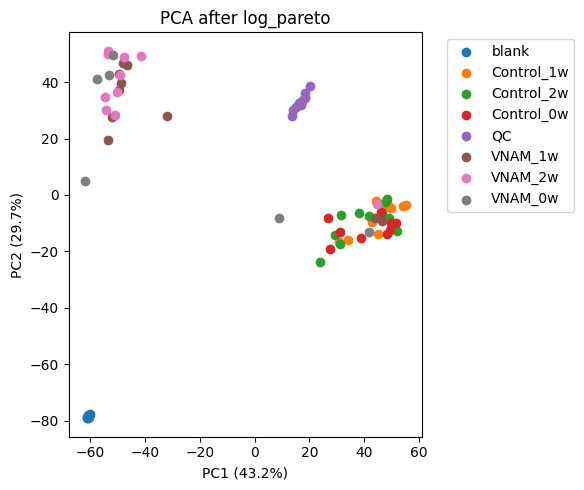

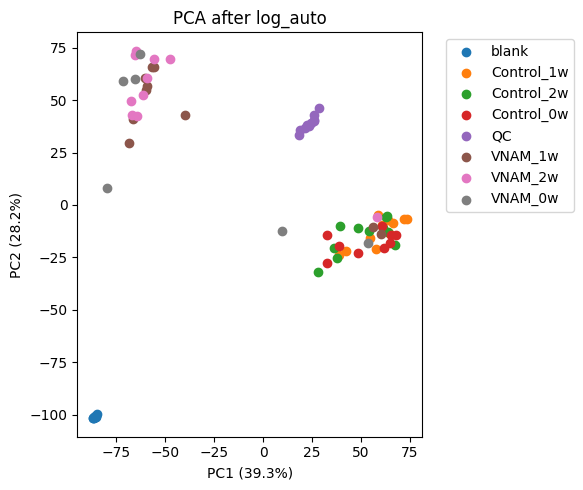

In [7]:
result_df, pca_outputs = compare_scaling_methods_pca(original_dataset, qc_label='QC')  #Edit: if your QC label is different, change 'QC' to the appropriate label in your dataset.
display(result_df)
plot_scaling_method_pca(pca_outputs)

## 5. Automatic recommendation text

The following cell prints a brief recommendation based on the PCA results.

Use this recommendation as a starting point and review the PCA plots before making the final selection.

In [8]:
def make_scaling_recommendation_text(result_df):
    if result_df is None or len(result_df) == 0:
        print('No PCA comparison results are available.')
        return None

    df_valid = result_df.dropna(subset=['qc_cluster_score']).copy()
    if len(df_valid) == 0:
        print('QC-based recommendation is not available.')
        print('Please check whether QC samples exist and whether the QC label is correct.')
        return None

    best = df_valid.iloc[0]
    worst = df_valid.iloc[-1]

    print('=== Automatic recommendation ===')
    print(f"Best starting option based on QC clustering: {best['method']}")
    print(f"QC cluster score: {best['qc_cluster_score']:.4f}")
    print()
    print('Reasoning:')
    print(f"- Among the tested methods, '{best['method']}' produced the tightest QC clustering in PCA space.")
    print('- Tighter QC clustering generally suggests more stable technical behavior after scaling.')

    if best['method'] == 'log_pareto':
        print('- This often suggests that the raw data are right-skewed and benefit from log transform before scaling.')
    elif best['method'] == 'pareto':
        print('- This often suggests a balanced choice that reduces dominance of large features without over-amplifying noise.')
    elif best['method'] == 'auto':
        print('- This suggests equalizing variance helps, but you should still check whether noise is being amplified.')
    elif best['method'] == 'none':
        print('- This suggests that stronger scaling may not be improving QC behavior in this dataset.')

    print()
    print('Comparison note:')
    print(f"- The weakest tested option by QC clustering was '{worst['method']}' with qc_cluster_score = {worst['qc_cluster_score']:.4f}.")
    print()
    print('Practical advice:')
    print('- Use this recommendation as a starting point, not as an absolute rule.')
    print('- Also review the PCA plots directly and confirm that QC samples cluster tightly without suspicious distortion of biological groups.')
    print('- If two methods have very similar QC cluster scores, pareto is often the safer and more interpretable choice.')

    return {
        'recommended_method': best['method'],
        'recommended_qc_cluster_score': float(best['qc_cluster_score'])
    }

In [9]:
recommendation = make_scaling_recommendation_text(result_df)
recommendation

=== Automatic recommendation ===
Best starting option based on QC clustering: log_pareto
QC cluster score: 2.9122

Reasoning:
- Among the tested methods, 'log_pareto' produced the tightest QC clustering in PCA space.
- Tighter QC clustering generally suggests more stable technical behavior after scaling.
- This often suggests that the raw data are right-skewed and benefit from log transform before scaling.

Comparison note:
- The weakest tested option by QC clustering was 'none' with qc_cluster_score = 725425011.1073.

Practical advice:
- Use this recommendation as a starting point, not as an absolute rule.
- Also review the PCA plots directly and confirm that QC samples cluster tightly without suspicious distortion of biological groups.
- If two methods have very similar QC cluster scores, pareto is often the safer and more interpretable choice.


{'recommended_method': 'log_pareto',
 'recommended_qc_cluster_score': 2.9121781121868535}

## 6. Final note

After reviewing the recommended scaling method, use the selected option in the main preprocessing notebook.

Example:

```python
preprocessor = MetaboPreprocessor(
    step_blank_subtraction=True,
    step_filter_rsd=True,
    qc_label='Mix',
    blank_label='blank',
    scaling='pareto'
)
```
